# Example usage of the ofset free koopman MPC

In [42]:
import sys
import os
import numpy as np
#import pandas as pd
import joblib
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch
from sklearn.preprocessing import StandardScaler

from neuromancer.system import Node, System
from neuromancer.trainer import Trainer
from neuromancer.problem import Problem
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer. modules import blocks

# Add 'src' to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
src_path = os.path.join(project_root, 'src')
sys.path.append(src_path)

import models
import helper
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading a Dataset

## Preparing data for training koopman models

In [43]:
def get_data(train_sim, dev_sim, test_sim, nsteps, bs, scaler, scalerU):
    
    ny = train_sim['Y'].shape[1]
    nu = train_sim['U'].shape[1]
    
    nsim = train_sim['Y'].shape[0]
    nbatch = nsim//nsteps
    length = (nsim//nsteps) * nsteps

    trainX = scaler.transform(train_sim['Y'][:length])
    trainX = trainX.reshape(nbatch, nsteps, ny)
    trainX = torch.tensor(trainX, dtype=torch.float32)
    trainU = scalerU.transform(train_sim['U'][:length])
    trainU = trainU.reshape(nbatch, nsteps, nu)
    trainU = torch.tensor(trainU, dtype=torch.float32)
    train_data = DictDataset({'Y': trainX, 'Y0': trainX[:, 0:1, :],
                              'U': trainU}, name='train')
    train_loader = DataLoader(train_data, batch_size=bs,
                              collate_fn=train_data.collate_fn, shuffle=True)
    
    nsim = dev_sim['Y'].shape[0]
    nbatch = nsim//nsteps
    length = (nsim//nsteps) * nsteps
    
    devX = scaler.transform(dev_sim['Y'][:length])
    devX = devX.reshape(nbatch, nsteps, ny)
    devX = torch.tensor(devX, dtype=torch.float32)
    devU = scalerU.transform(dev_sim['U'][:length])
    devU = devU[:length].reshape(nbatch, nsteps, nu)
    devU = torch.tensor(devU, dtype=torch.float32)
    dev_data = DictDataset({'Y': devX, 'Y0': devX[:, 0:1, :],
                            'U': devU}, name='dev')
    dev_loader = DataLoader(dev_data, batch_size=bs,
                            collate_fn=dev_data.collate_fn, shuffle=True)

    nsim = test_sim['Y'].shape[0]
    nbatch = nsim//nsteps
    length = (nsim//nsteps) * nsteps
    
    testX = scaler.transform(test_sim['Y'][:length])
    testX = testX.reshape(1, nbatch*nsteps, ny)
    testX = torch.tensor(testX, dtype=torch.float32)
    testU = scalerU.transform(test_sim['U'][:length])
    testU = testU.reshape(1, nbatch*nsteps, nu)
    testU = torch.tensor(testU, dtype=torch.float32)
    test_data = {'Y': testX, 'Y0': testX[:, 0:1, :],
                 'U': testU}
    
    trainX = scaler.transform(train_sim['Y'][:length])
    trainX = trainX.reshape(1, nbatch*nsteps, ny)
    trainX = torch.tensor(trainX, dtype=torch.float32)
    trainU = scalerU.transform(train_sim['U'][:length])
    trainU = trainU.reshape(1, nbatch*nsteps, nu)
    trainU = torch.tensor(trainU, dtype=torch.float32)
    train_data_forC = {'Y': trainX, 'Y0': trainX[:, 0:1, :],
                 'U': trainU}

    return train_loader, dev_loader, test_data, train_data_forC

In [44]:
# Load CSTR-separator identification data
# Y: [T1, T2, T3, xB3], U: [Q1, Q2, Q3, F10]
data = np.load('../data/cstr_separator_ident.npz', allow_pickle=True)
sim = {'Y': np.array(data['Y'], dtype=float), 'U': np.array(data['U'], dtype=float)}

n_train, n_dev = 7200, 1600  # remaining 1200 -> test; all divisible by nsteps=80

# Y already includes range-aware measurement noise from the npz.
if 'noise_sigma' in data.files:
    print('Stored measurement noise (already in Y):')
    for name, s in zip(data['y_names'], np.array(data['noise_sigma'], dtype=float)):
        print(f'  {name}: sigma={s:.4g}')

train = {key: value[:n_train] for key, value in sim.items()}
dev = {key: value[n_train:n_train + n_dev] for key, value in sim.items()}
test = {key: value[n_train + n_dev:] for key, value in sim.items()}

print('Loaded', '../data/cstr_separator_ident.npz')
print('Y', sim['Y'].shape, list(data['y_names']))
print('U', sim['U'].shape, list(data['u_names']))
print('train', train['Y'].shape, 'dev', dev['Y'].shape, 'test', test['Y'].shape)


Loaded 13 experiments from ../ident_data/

SUMMARY: ident_data loaded successfully (T2, T4 | u2, u3)
ident_data: experiments 0 to 12
Training experiments: [0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11]
Test experiments: [7, 12]
Training samples (combined): 6600  (ny=2, nu=2)
Test samples (combined): 1200
Individual experiment lengths: [600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600]


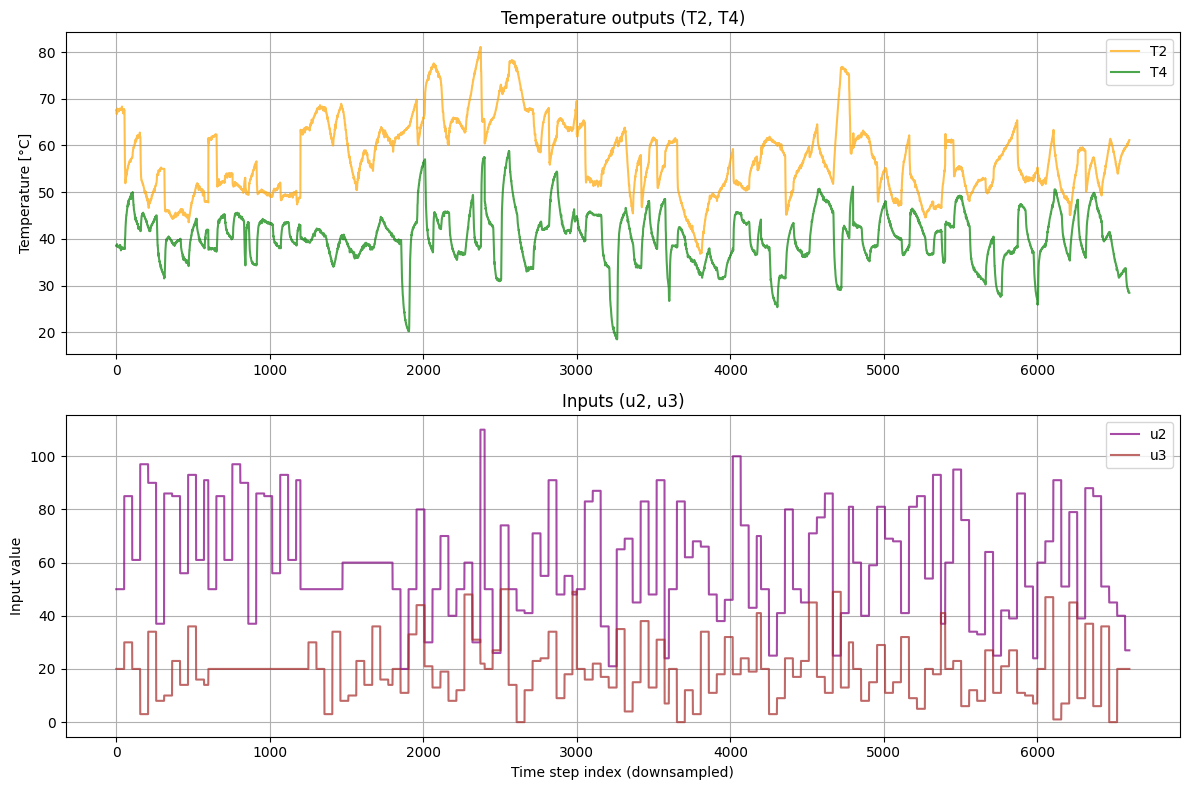

In [45]:
part = 2000
y_names = ['T1', 'T2', 'T3', 'xB3']
u_names = ['Q1', 'Q2', 'Q3', 'F10']

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for i, name in enumerate(y_names):
    axes[0].plot(train['Y'][:part, i], label=name)
axes[0].set_ylabel('Outputs')
axes[0].set_title('Train measured outputs')
axes[0].legend()
for i, name in enumerate(u_names):
    axes[1].plot(train['U'][:part, i], label=name)
axes[1].set_xlabel('Time steps [s]')
axes[1].set_ylabel('Inputs')
axes[1].set_title('Train manipulated inputs')
axes[1].legend()
plt.tight_layout()
plt.show()


In [46]:
nsteps = 80   # number of prediction horizon steps in the loss function
bs = 80      # minibatching batch size


In [47]:
# load scalers for scaling the data from saved files
scaler = StandardScaler()
scaler.fit(train['Y'])
joblib.dump(scaler, '../data/scaler_cstr_separator.pkl')

scalerU = StandardScaler()
scalerU.fit(train['U'])
joblib.dump(scalerU, '../data/scalerU_cstr_separator.pkl')


In [48]:
train_loader, dev_loader, test_data, train_data = get_data(train, dev, test, nsteps, bs, scaler, scalerU)


## Creating the model


In [49]:
# model parameters
nz = 8
ny = train['Y'].shape[1]
nu = train['U'].shape[1]

cons = 2
layers = [4*cons,8*cons,16*cons]
layers_dec  = [16*cons,8*cons,4*cons]

cons = 1
layers = [6*cons,12*cons,18*cons,24*cons]
layers_dec  = [24*cons,18*cons,12*cons,6*cons]

matrix_C = False

In [50]:
# instantiate output encoder neural net f_y
f_y = blocks.MLP(
    ny,
    nz,
    bias=True,
    linear_map=torch.nn.Linear,
    nonlin=torch.nn.ELU,
    hsizes=layers,
)
# initial condition encoder
encode_Y0 = Node(f_y, ['Y0'], ['x'], name='encoder_Y0')
# observed trajectory encoder
encode_Y = Node(f_y, ['Y'], ['x_latent'], name='encoder_Y')

In [51]:
# instantiate input encoder net f_u, representing the B matrix in the linear system
f_u = torch.nn.Linear(nu, nz, bias=False)
# initial condition encoder
encode_U = Node(f_u, ['U'], ['u_latent'], name='encoder_U')

In [52]:
# instantiate state decoder neural net f_y_inv
if not matrix_C:
    f_y_inv = blocks.MLP(nz, ny, bias=True,
                    linear_map=torch.nn.Linear,
                    nonlin=torch.nn.ELU,
                    hsizes=layers_dec)
elif matrix_C:
    f_y_inv = torch.nn.Linear(nz, ny, bias=False)
else:
    raise ValueError('matrix_C must be boolean')

# predicted trajectory decoder
decode_y = Node(f_y_inv, ['x'], ['yhat'], name='decoder_y')

In [53]:
# representing matrix A in the linear system
K = torch.nn.Linear(nz, nz, bias=False)

In [54]:
# symbolic Koopman model with control inputs
Koopman = Node(helper.PredictionWControl(K), ['x', 'u_latent'], ['x'], name='K')

# latent Koopmann rollout
dynamics_model = System([Koopman], name='Koopman', nsteps=nsteps)

In [55]:
# put all nodes of the Koopman model together in a list of nodes
nodes = [encode_Y0, encode_Y, encode_U, dynamics_model, decode_y]

### Define Koopman system identification loss function terms

In [56]:
# variables
Y = variable("Y")  # observed
yhat = variable('yhat')  # predicted output
x_latent = variable('x_latent')  # encoded output trajectory in the latent space
u_latent = variable('u_latent')  # encoded input trajectory in the latent space
x = variable('x')  # Koopman latent space trajectory

xu_latent = x_latent + u_latent  # latent state trajectory

# output trajectory tracking loss
y_loss = 10. * (yhat[:, 1:-1, :] == Y[:, 1:, :]) ^ 2
y_loss.name = "y_loss"

# one-step tracking loss
onestep_loss = 1.*(yhat[:, 1, :] == Y[:, 1, :])^2
onestep_loss.name = "onestep_loss"

# reconstruction loss
reconstruction_loss = 1 * (yhat[:, 0, :] == Y[:, 0, :])^2
reconstruction_loss.name = "reconstruction_loss"

# latent trajectory tracking loss
x_loss = 10. * (x[:, 1:-1, :] == xu_latent[:, 1:, :]) ^ 2
x_loss.name = "x_loss"

### Construct System learning problem

In [57]:
# aggregate list of objective terms and constraints
objectives = [y_loss, x_loss, onestep_loss, reconstruction_loss]

# create constrained optimization loss
loss = PenaltyLoss(objectives, constraints=[])

# construct constrained optimization problem
problem = Problem(nodes, loss)

In [58]:
problem.nodes

ModuleList(
  (0): encoder_Y0(Y0) -> x
  (1): encoder_Y(Y) -> x_latent
  (2): encoder_U(U) -> u_latent
  (3): System(
    (nodes): ModuleList(
      (0): K(x, u_latent) -> x
    )
  )
  (4): decoder_y(x) -> yhat
)

### Solve the problem

In [59]:
from neuromancer.trainer import Callback

class PrintCallback(Callback):
    def end_eval(self, trainer, output):
        if trainer.current_epoch % trainer.epoch_verbose == 0:
            train_loss = output.get('mean_train_loss', output.get('train_loss', 'N/A'))
            dev_loss = output.get('mean_dev_loss', output.get('dev_loss', 'N/A'))
            print(f"epoch: {trainer.current_epoch}  "
                  f"train_loss: {train_loss}  "
                  f"dev_loss: {dev_loss}")

optimizer = torch.optim.Adam(problem.parameters(), lr=0.001)

trainer = Trainer(
    problem,
    train_loader,
    dev_loader,
    test_data,
    optimizer,
    callback=PrintCallback(),
    patience=300,
    warmup=100,
    epochs=3000,
    eval_metric="dev_loss",
    train_metric="train_loss",
    dev_metric="dev_loss",
    test_metric="dev_loss",
)


In [60]:
# train

best_model = trainer.train()
problem.load_state_dict(best_model)


epoch: 0  train_loss: 14.34047794342041
epoch: 0  train_loss: 14.34047794342041  dev_loss: 12.894200325012207
epoch: 1  train_loss: 14.004851341247559
epoch: 1  train_loss: 14.004851341247559  dev_loss: 12.567366600036621
epoch: 2  train_loss: 13.663542747497559
epoch: 2  train_loss: 13.663542747497559  dev_loss: 12.276774406433105
epoch: 3  train_loss: 13.049535751342773
epoch: 3  train_loss: 13.049535751342773  dev_loss: 12.010560035705566
epoch: 4  train_loss: 13.423812866210938
epoch: 4  train_loss: 13.423812866210938  dev_loss: 11.753178596496582
epoch: 5  train_loss: 12.56071662902832
epoch: 5  train_loss: 12.56071662902832  dev_loss: 11.513158798217773
epoch: 6  train_loss: 13.546697616577148
epoch: 6  train_loss: 13.546697616577148  dev_loss: 11.283225059509277
epoch: 7  train_loss: 12.667533874511719
epoch: 7  train_loss: 12.667533874511719  dev_loss: 11.062102317810059
epoch: 8  train_loss: 11.756705284118652
epoch: 8  train_loss: 11.756705284118652  dev_loss: 10.848135948181

<All keys matched successfully>

### Saving model and evaluation of the training

In [61]:
# save model
torch.save(best_model, "../data/model_cstr_separator_C_" + str(matrix_C) + ".pth")

# pull matrices
A = K.weight.detach().numpy()
B = f_u.weight.detach().numpy()
if matrix_C:
    C = f_y_inv.weight.detach().numpy()
    
elif not matrix_C:
    # get approximate C matrix from training data
    problem.nodes[3].nsteps = train_data['Y'].shape[1]
    train_outputs = problem.step(train_data)

    Y = train_data['Y'].reshape(-1, ny).detach().numpy()
    Z = train_outputs['x'][:,:-1,:].detach().numpy().reshape(-1, nz)
    rankZ = np.linalg.matrix_rank(Z)
    if rankZ < nz:
        print('Rank deficient Z matrix, can result in bad fitted C matrix!')
        print(f'Rank of Z: {rankZ}, nz: {nz}')
    C, residuals, rank, s = np.linalg.lstsq(Z, Y, rcond=None)
    C = C.T

else:
    raise ValueError('matrix_C must be boolean')


In [62]:
from numpy.linalg import matrix_rank

# Compute the controllability matrix
n_states = A.shape[0]
controllability_matrix = np.hstack([np.linalg.matrix_power(A, i) @ B for i in range(n_states)])

# Check the rank of the controllability matrix
controllability_rank = matrix_rank(controllability_matrix)

print(f"Controllability Matrix Rank: {controllability_rank}")
print(f"System is {'controllable' if controllability_rank == n_states else 'not controllable'}")

# Compute the observability matrix
observability_matrix = np.vstack([C @ np.linalg.matrix_power(A, i) for i in range(n_states)])

# Check the rank of the observability matrix
observability_rank = matrix_rank(observability_matrix)

print(f"Observability Matrix Rank: {observability_rank}")
print(f"System is {'observable' if observability_rank == n_states else 'not observable'}")

Controllability Matrix Rank: 8
System is controllable
Observability Matrix Rank: 8
System is observable


In [63]:
np.save('../data/A_cstr_separator_C_' + str(matrix_C) + '.npy', A)
np.save('../data/B_cstr_separator_C_' + str(matrix_C) + '.npy', B)
np.save('../data/C_cstr_separator_C_' + str(matrix_C) + '.npy', C)


In [64]:
# update the rollout length based on the test data
problem.nodes[3].nsteps = test_data['Y'].shape[1]

In [65]:
# do the prediction
test_outputs = problem.step(test_data)

pred_traj = test_outputs['yhat'][:, 1:-1, :].detach().numpy().reshape(-1, ny).T
true_traj = test_data['Y'][:, 1:pred_traj.shape[1]+1, ].detach().numpy().reshape(-1, ny).T
input_traj = test_data['U'].detach().numpy().reshape(-1, nu).T
pred_x = test_outputs['x'][:, 1:-1, :].detach().numpy().reshape(-1, nz).T

In [66]:
pred_traj_C = np.dot(C, pred_x)

In [67]:
x_mean = np.mean(pred_x, axis=1, keepdims=True)
x_med = np.median(pred_x, axis=1, keepdims=True)

In [68]:
def get_y_from_x(problem, x: np.ndarray) -> np.ndarray:
    y = problem.nodes[4]({"x": torch.from_numpy(x.T).float()})
    return y["yhat"].detach().numpy().reshape(1, -1)

In [69]:
J = helper.evaluate_jacobian(
    problem.nodes[4],
    torch.from_numpy(x_mean[:,0]).float(),
)
# Get all latent states from training data
x_train = train_outputs['x'].detach().numpy().reshape(-1, nz)

# Evaluate Jacobian for each latent state
J_all = np.stack([
    helper.evaluate_jacobian(problem.nodes[4], torch.from_numpy(xi).float())
    for xi in x_train
])

bias_all = np.stack([
    get_y_from_x(problem, xi.reshape(-1,1))
    for xi in x_train
])

# Compute mean Jacobian
J_mean = np.mean(J_all, axis=0)
print("Mean Jacobian J_mean:\n", J_mean) # mean bias?

bias_mean = np.mean(bias_all, axis=0)
print("Mean Bias:\n", bias_mean)


pred_traj_J = np.dot(J_mean, pred_x - x_mean) #+ bias_mean.T

Mean Jacobian J_mean:
 [[ 0.58265114  0.40918097 -1.1424311  -0.6127363  -0.1230528  -0.01380478
   0.79089606 -0.6858367 ]
 [-2.0382168   0.14859998  0.0636336  -0.9133445  -0.18600935 -1.6309593
  -0.34009615 -2.1909108 ]]
Mean Bias:
 [[-0.6054182  0.3132189]]


In [70]:
x_lin = np.zeros((nz,1))
J = helper.evaluate_jacobian(
    problem.nodes[4],
    torch.from_numpy(x_lin[:,0]).float(),
)

bias = get_y_from_x(problem, x_lin)
pred_traj_J = np.dot(J, pred_x - x_lin) + bias.T

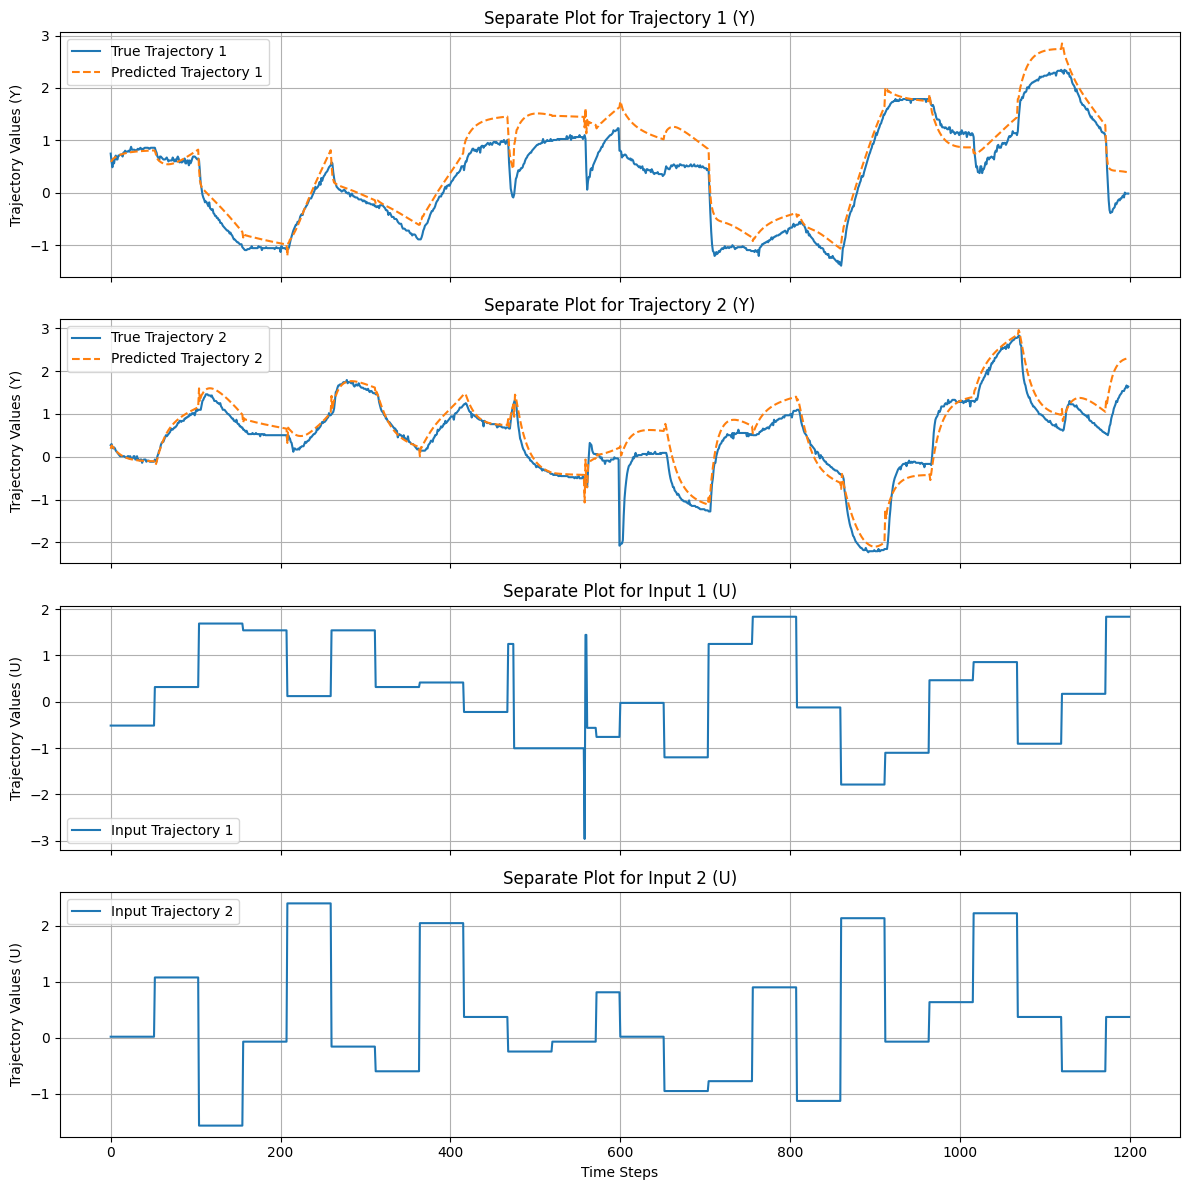

In [71]:
fig, axs = plt.subplots(ny + nu, 1, figsize=(12, 3 * (ny + nu)), sharex=True)

# Separate plots for each vector in Y
for i in range(ny):
    axs[i].plot(true_traj[i], label=f'True Trajectory {i + 1}', linestyle='-')
    axs[i].plot(pred_traj[i], label=f'Predicted Trajectory {i + 1}', linestyle='--')
    # axs[i].plot(pred_traj_C[i], label=f'Predicted Trajectory {i + 1} C', linestyle='--')
    #axs[i].plot(pred_traj_J[i], label=f'Predicted Trajectory {i + 1} J', linestyle='--')
    axs[i].set_title(f'Separate Plot for Trajectory {i + 1} (Y)')
    axs[i].legend()
    axs[i].grid()

# Separate plots for each vector in U
for i in range(nu):
    axs[ny + i].plot(input_traj[i], label=f'Input Trajectory {i + 1}', linestyle='-')
    axs[ny + i].set_title(f'Separate Plot for Input {i + 1} (U)')
    axs[ny + i].legend()
    axs[ny + i].grid()

# Add labels
axs[-1].set_xlabel('Time Steps')
for i in range(ny):
    axs[i].set_ylabel('Trajectory Values (Y)')
for i in range(nu):
    axs[ny + i].set_ylabel('Trajectory Values (U)')

plt.tight_layout()
plt.show()


In [72]:
# calculate MAE of predicted trajectories
mae_pred = np.mean(np.abs(true_traj[:, :] - pred_traj[:, :]), axis=1)
mae_pred_C = np.mean(np.abs(true_traj[:, :] - pred_traj_C[:, :]), axis=1)
mae_pred_J = np.mean(np.abs(true_traj[:, :] - pred_traj_J[:, :]), axis=1)
print(f'MAE of predicted trajectory: {sum(mae_pred)}')
print(f'MAE of predicted trajectory C: {sum(mae_pred_C)}')
print(f'MAE of predicted trajectory J: {sum(mae_pred_J)}')

MAE of predicted trajectory: 0.5417987704277039
MAE of predicted trajectory C: 0.6007120013237
MAE of predicted trajectory J: 0.8734620376714146


In [73]:
# Calculate variance of mismatch (error) between test data and predicted data
var_error_pred = np.var(true_traj - pred_traj, axis=1)
var_error_pred_C = np.var(true_traj - pred_traj_C, axis=1)
var_error_pred_J = np.var(true_traj - pred_traj_J, axis=1)

print(f'Variance of mismatch (True - Predicted): {var_error_pred}')
print(f'Variance of mismatch (True - Predicted C): {var_error_pred_C}')
print(f'Variance of mismatch (True - Predicted J): {var_error_pred_J}')



Variance of mismatch (True - Predicted): [0.06534281 0.07818194]
Variance of mismatch (True - Predicted C): [0.10573652 0.18770787]
Variance of mismatch (True - Predicted J): [0.43810831 0.14620811]


In [74]:
# Calculate mean squared error (MSE) of all test predictions
mse_pred = np.mean((true_traj - pred_traj) ** 2)
mse_pred_C = np.mean((true_traj - pred_traj_C) ** 2)
mse_pred_J = np.mean((true_traj - pred_traj_J) ** 2)

print(f'MSE of predicted trajectory: {mse_pred}')
print(f'MSE of predicted trajectory C: {mse_pred_C}')
print(f'MSE of predicted trajectory J: {mse_pred_J}')


MSE of predicted trajectory: 0.12411858886480331
MSE of predicted trajectory C: 0.1632223129272461
MSE of predicted trajectory J: 0.3257210521580441


In [75]:
# Define lower and upper bounds for true_traj values
lower_bound = -0.50
upper_bound = 0.50

# Create mask for values within the specified range
mask = (true_traj >= lower_bound) & (true_traj <= upper_bound)

# Compute MAE only for masked values
mae_pred_masked = [np.mean(np.abs(true_traj[i][mask[i]] - pred_traj[i][mask[i]])) for i in range(true_traj.shape[0])]
mae_pred_C_masked = [np.mean(np.abs(true_traj[i][mask[i]] - pred_traj_C[i][mask[i]])) for i in range(true_traj.shape[0])]
mae_pred_J_masked = [np.mean(np.abs(true_traj[i][mask[i]] - pred_traj_J[i][mask[i]])) for i in range(true_traj.shape[0])]

print(f'Masked MAE of predicted trajectory: {mae_pred_masked}')
print(f'Masked MAE of predicted trajectory C: {mae_pred_C_masked}')
print(f'Masked MAE of predicted trajectory J: {mae_pred_J_masked}')

Masked MAE of predicted trajectory: [np.float32(0.32193184), np.float32(0.21267605)]
Masked MAE of predicted trajectory C: [np.float32(0.37230164), np.float32(0.20013408)]
Masked MAE of predicted trajectory J: [np.float64(0.49306755275839026), np.float64(0.19713298509659383)]


In [76]:
J_mean

array([[ 0.58265114,  0.40918097, -1.1424311 , -0.6127363 , -0.1230528 ,
        -0.01380478,  0.79089606, -0.6858367 ],
       [-2.0382168 ,  0.14859998,  0.0636336 , -0.9133445 , -0.18600935,
        -1.6309593 , -0.34009615, -2.1909108 ]], dtype=float32)

In [77]:
C

array([[  6.7835393 ,   8.546831  ,  10.400106  ,  -5.5531373 ,
          1.6790618 ,  -7.9615417 ,   2.622882  ,   1.590724  ],
       [  7.6431193 ,  11.709809  ,  21.916786  ,  -6.6079245 ,
          4.4325156 , -17.029844  ,   3.0552819 ,   0.02535394]],
      dtype=float32)

In [78]:
# mse C-J
mse_C_J = np.mean((C - J_mean) ** 2)
print("Mean Squared Error between C and J_mean:\n", mse_C_J)
# mse C-J
mse_C_J = np.mean((C - J) ** 2)
print("Mean Squared Error between C and J:\n", mse_C_J)

Mean Squared Error between C and J_mean:
 84.346146
Mean Squared Error between C and J:
 84.3496


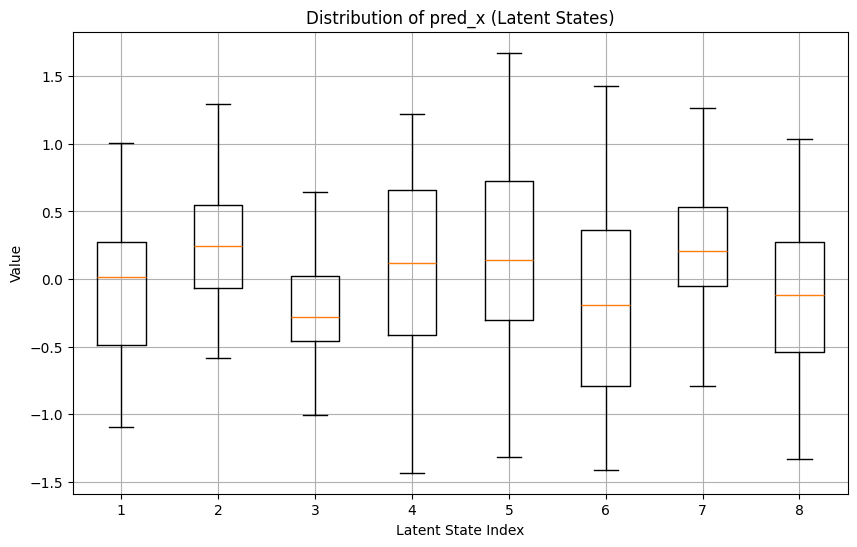

In [79]:
plt.figure(figsize=(10, 6))
plt.boxplot(pred_x.T)
plt.title('Distribution of pred_x (Latent States)')
plt.xlabel('Latent State Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

## Open-loop simulation with zero inputs


In [80]:
# Set up open-loop simulation parameters
n_sim_steps = 500

# Use mean of training data as initial condition (in original scale)
Y0_mean = np.mean(train['Y'], axis=0).reshape(1, 1, ny)

# Scale the initial condition
Y0_scaled = scaler.transform(Y0_mean.reshape(1, -1)).reshape(1, 1, ny)
Y0_tensor = torch.tensor(Y0_scaled, dtype=torch.float32)

# Create zero inputs for all simulation steps (in original scale)
U_scaled = np.zeros((1, n_sim_steps, nu))
U_tensor = torch.tensor(U_scaled, dtype=torch.float32)

# Create dummy Y vector as zeros for all simulation steps
Y_dummy_scaled = np.zeros((1, n_sim_steps, ny))
Y_dummy_tensor = torch.tensor(Y_dummy_scaled, dtype=torch.float32)

# Create simulation data dictionary, adding dummy Y
sim_data = {
    'Y0': Y0_tensor,
    'U': U_tensor,
    'Y': Y_dummy_tensor
}

print(f"Initial condition (scaled): {Y0_scaled.flatten()}")
print(f"Input shape: {U_tensor.shape}")
print(f"Dummy Y shape: {Y_dummy_tensor.shape}")
print(f"Simulation will run for {n_sim_steps} steps")


Initial condition (scaled): [0. 0.]
Input shape: torch.Size([1, 500, 2])
Dummy Y shape: torch.Size([1, 500, 2])
Simulation will run for 500 steps


In [81]:
# Update the rollout length for simulation
problem.nodes[3].nsteps = n_sim_steps

# Run the open-loop simulation
sim_outputs = problem.step(sim_data)

# Extract predicted outputs
sim_yhat = sim_outputs['yhat'][:, 1:-1, :].detach().numpy().reshape(-1, ny)

# Unscale the outputs to original scale
sim_yhat_unscaled = scaler.inverse_transform(sim_yhat)

# Extract latent states
sim_x = sim_outputs['x'][:, 1:-1, :].detach().numpy().reshape(-1, nz)

print(f"Simulation completed!")
print(f"Output shape: {sim_yhat_unscaled.shape}")
print(f"Latent state shape: {sim_x.shape}")


Simulation completed!
Output shape: (499, 2)
Latent state shape: (499, 8)


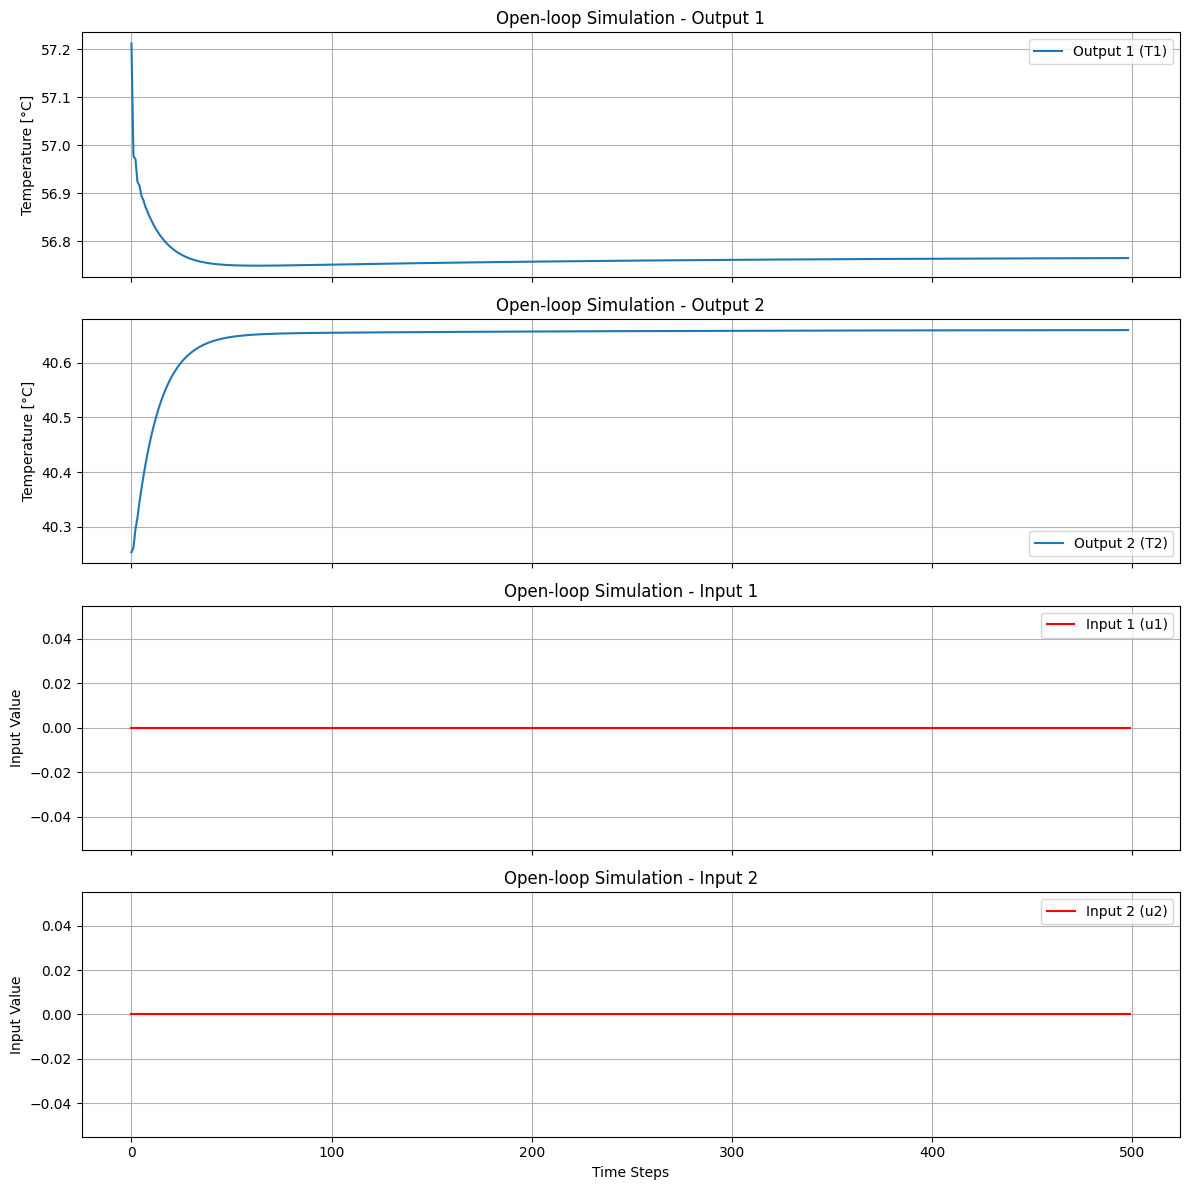


Simulation Statistics:
Final output values: [56.764675 40.659554]
Output range: [[56.74886  40.253174], [57.21192  40.659554]]
Output mean: [56.76354  40.646564]
Output std: [0.03005288 0.04805716]


In [82]:
# Plot the open-loop simulation results
fig, axs = plt.subplots(ny + nu, 1, figsize=(12, 3 * (ny + nu)), sharex=True)

# Plot outputs
for i in range(ny):
    axs[i].plot(sim_yhat_unscaled[:, i], label=f'Output {i + 1} (T{i+1 if i < 3 else i+1})', linewidth=1.5)
    axs[i].set_title(f'Open-loop Simulation - Output {i + 1}')
    axs[i].set_ylabel('Temperature [°C]')
    axs[i].legend()
    axs[i].grid(True)

# Plot inputs (zeros)
for i in range(nu):
    axs[ny + i].plot(U_scaled[0, :, i], label=f'Input {i + 1} (u{i+1})', linewidth=1.5, color='red')
    axs[ny + i].set_title(f'Open-loop Simulation - Input {i + 1}')
    axs[ny + i].set_ylabel('Input Value')
    axs[ny + i].legend()
    axs[ny + i].grid(True)

# Add x-axis label to the last subplot
axs[-1].set_xlabel('Time Steps')

plt.tight_layout()
plt.show()

# Print some statistics
print("\nSimulation Statistics:")
print(f"Final output values: {sim_yhat_unscaled[-1, :]}")
print(f"Output range: [{sim_yhat_unscaled.min(axis=0)}, {sim_yhat_unscaled.max(axis=0)}]")
print(f"Output mean: {sim_yhat_unscaled.mean(axis=0)}")
print(f"Output std: {sim_yhat_unscaled.std(axis=0)}")
